In [28]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import numpy as np
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.utils import to_categorical
import matplotlib.pyplot as plt

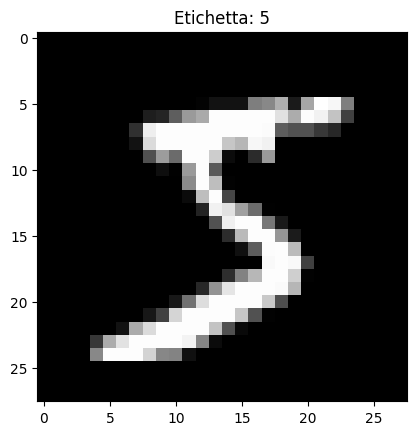

In [29]:
# Caricamento del dataset MNIST

(X_train, y_train), (X_test, y_test) = mnist.load_data()


# Visualizzazione di un esempio

plt.imshow(X_train[0], cmap='gray')

plt.title(f'Etichetta: {y_train[0]}')

plt.show()


# Normalizzazione dei dati, le reti neurali funzionano SOLO con dati normalizzati

X_train = X_train.astype('float32') / 255

X_test = X_test.astype('float32') / 255


# Reshape dei dati

X_train = X_train.reshape(-1, 28*28)

X_test = X_test.reshape(-1, 28*28)


# Conversione delle etichette in formato one-hotencoding

y_train = to_categorical(y_train, num_classes=10)

y_test = to_categorical(y_test, num_classes=10)

In [30]:
# Creazione del modello

model = Sequential()


# Aggiunta degli strati

model.add(Dense(units=128, activation='relu', input_shape=(784,)))

model.add(Dropout(0.3))

model.add(Dense(units=64, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(units=10, activation='softmax'))



c:\Users\mbagn\anaconda3\envs\pytorch\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(optimizer='adam',

              loss='categorical_crossentropy',

              metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train,

                    epochs=20,

                    batch_size=32,

                    validation_split=0.1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9722 - loss: 0.0909 - val_accuracy: 0.9803 - val_loss: 0.0682
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9743 - loss: 0.0833 - val_accuracy: 0.9807 - val_loss: 0.0710
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9749 - loss: 0.0812 - val_accuracy: 0.9810 - val_loss: 0.0669
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9764 - loss: 0.0786 - val_accuracy: 0.9812 - val_loss: 0.0722
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9768 - loss: 0.0772 - val_accuracy: 0.9817 - val_loss: 0.0695
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9765 - loss: 0.0738 - val_accuracy: 0.9807 - val_loss: 0.0687
Epoch 7/20
 366/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9787 - loss: 0.0667

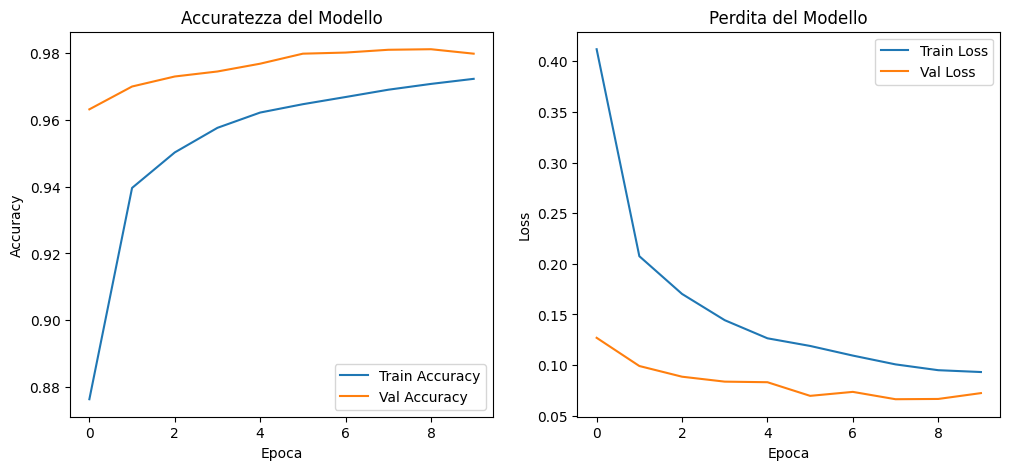

In [34]:
import matplotlib.pyplot as plt

# Creiamo una figura con due grafici (Sottoplot)
plt.figure(figsize=(12, 5))

# Grafico della Precisione (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuratezza del Modello')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

# Grafico della Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Perdita del Modello')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [35]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f'Perdita sul test set: {test_loss:.4f}')

print(f'Accuratezza sul test set: {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9767 - loss: 0.0844
Perdita sul test set: 0.0844
Accuratezza sul test set: 0.9767
